# 🔮 Prédiction du Divorce — Machine Learning

**Auteure :** Nada Ben Alaya  
**Dataset :** Étude psychologique réelle — Yöntem et al. (2019)  
**Objectif :** Prédire si un couple va divorcer à partir de 54 questions comportementales (classification binaire)

---
### Pipeline
1. Chargement & exploration des données (EDA)
2. Visualisation des corrélations
3. Préparation des features
4. Entraînement de 3 modèles ML
5. Comparaison des performances
6. Feature Importances & interprétation

Pourquoi ce sujet ?
Ce projet m'a intrigué parce qu'il se situe à l'intersection entre psychologie et data science — deux domaines qui me passionnent. 
J'ai voulu voir si un modèle ML pouvait capturer des dynamiques humaines aussi complexes que la rupture d'un couple, 
et surtout, quelles questions comportementales s'avèrent les plus révélatrices.

## 1. Imports & Chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('divorce.csv', sep=';')
print(f"Dimensions du dataset : {df.shape}")
print(f"→ {df.shape[0]} couples, {df.shape[1]-1} features + 1 cible\n")
df.head()

Dimensions du dataset : (170, 55)
→ 170 couples, 54 features + 1 cible



,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q46,Q47,Q48,Q49,Q50,Q51,Q52,Q53,Q54,Divorce
0,2,2,4,1,0,0,0,0,0,0,...,2,1,3,3,3,2,3,2,1,1
1,4,4,4,4,4,0,0,4,4,4,...,2,2,3,4,4,4,4,2,2,1
2,2,2,2,2,1,3,2,1,1,2,...,3,2,3,1,1,1,2,2,2,1
3,3,2,3,2,3,3,3,3,3,3,...,2,2,3,3,3,3,2,2,2,1
4,2,2,1,1,1,1,0,0,0,0,...,2,1,2,3,2,2,2,1,0,1


## 2. Exploration des données (EDA)

On vérifie la qualité du dataset : valeurs manquantes, doublons, équilibre des classes.

In [2]:
print(f"Valeurs manquantes : {df.isnull().sum().sum()} ✅")
print(f"Doublons : {df.duplicated().sum()} ⚠️")
print(f"\nRépartition de la cible :")
print(df['Divorce'].value_counts().rename({0: 'Marié', 1: 'Divorcé'}))

Valeurs manquantes : 0 ✅
Doublons : 20 ⚠️

Répartition de la cible :
Divorce
Marié      86
Divorcé    84
Name: count, dtype: int64


## 3. Visualisation — Répartition des classes

Le dataset est bien équilibré (86 mariés / 84 divorcés), ce qui est idéal pour la classification.

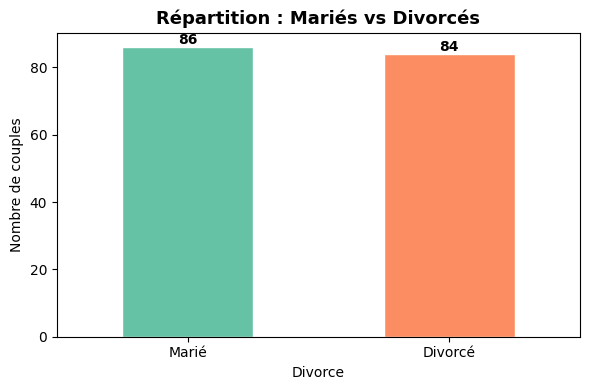

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['Divorce'].value_counts()
counts.plot(kind='bar', ax=ax, color=['#66c2a5', '#fc8d62'], edgecolor='white', width=0.5)
ax.set_title("Répartition : Mariés vs Divorcés", fontsize=13, fontweight='bold')
ax.set_xticklabels(['Marié', 'Divorcé'], rotation=0)
ax.set_ylabel("Nombre de couples")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Visualisation — Corrélations avec le divorce

On calcule la corrélation de Pearson entre chaque question et la variable cible `Divorce`.
- 🔴 Corrélation positive → la question est associée au divorce
- 🟢 Corrélation négative → la question est associée au maintien du mariage

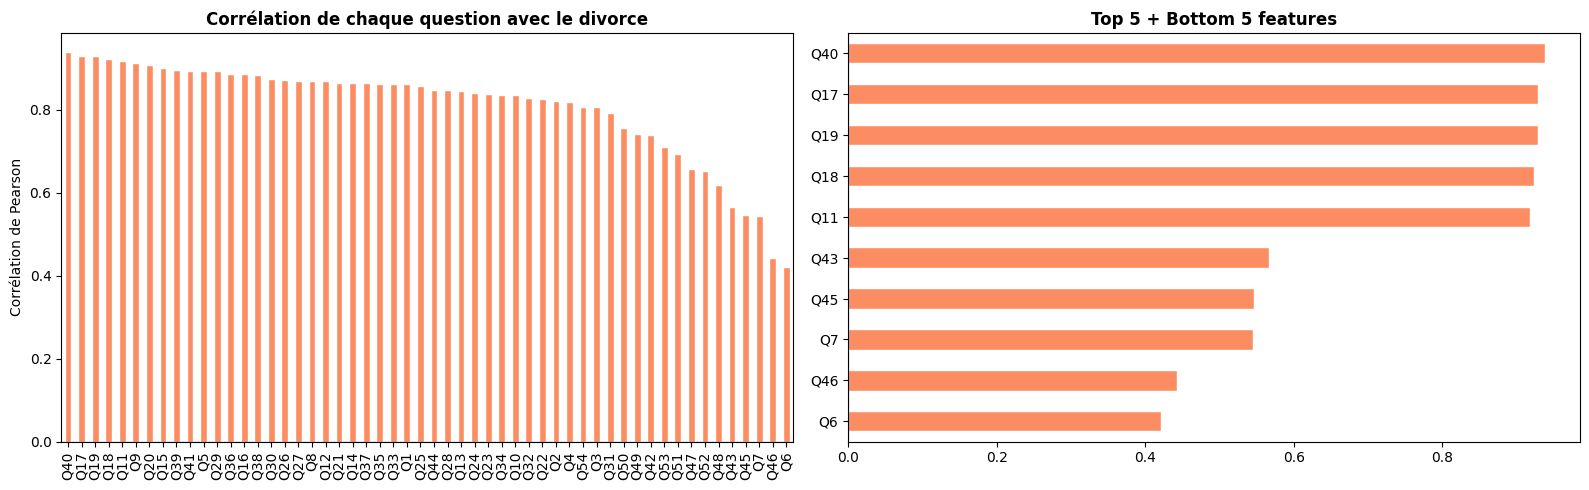


🔴 Top 5 questions qui PRÉDISENT le divorce :
  Q40 → 0.939
  Q17 → 0.929
  Q19 → 0.929
  Q18 → 0.923
  Q11 → 0.918

🟢 Top 5 questions qui PRÉDISENT le maintien du mariage :
  Q43 → 0.566
  Q45 → 0.546
  Q7 → 0.545
  Q46 → 0.443
  Q6 → 0.421


In [4]:
correlations = df.corr()['Divorce'].drop('Divorce').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Toutes les corrélations
correlations.plot(kind='bar', ax=axes[0],
                  color=['#fc8d62' if v > 0 else '#66c2a5' for v in correlations],
                  edgecolor='white')
axes[0].set_title("Corrélation de chaque question avec le divorce", fontweight='bold')
axes[0].set_ylabel("Corrélation de Pearson")
axes[0].axhline(0, color='black', linewidth=0.8)

# Top 10 zoom
top10 = pd.concat([correlations.head(5), correlations.tail(5)])
top10.plot(kind='barh', ax=axes[1],
           color=['#fc8d62' if v > 0 else '#66c2a5' for v in top10],
           edgecolor='white')
axes[1].set_title("Top 5 + Bottom 5 features", fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n🔴 Top 5 questions qui PRÉDISENT le divorce :")
for q, v in correlations.head(5).items():
    print(f"  {q} → {v:.3f}")

print("\n🟢 Top 5 questions qui PRÉDISENT le maintien du mariage :")
for q, v in correlations.tail(5).items():
    print(f"  {q} → {v:.3f}")

## 5. Heatmap — Intercorrélations entre les top features

On visualise les corrélations entre les 10 questions les plus importantes pour détecter d'éventuelles redondances.

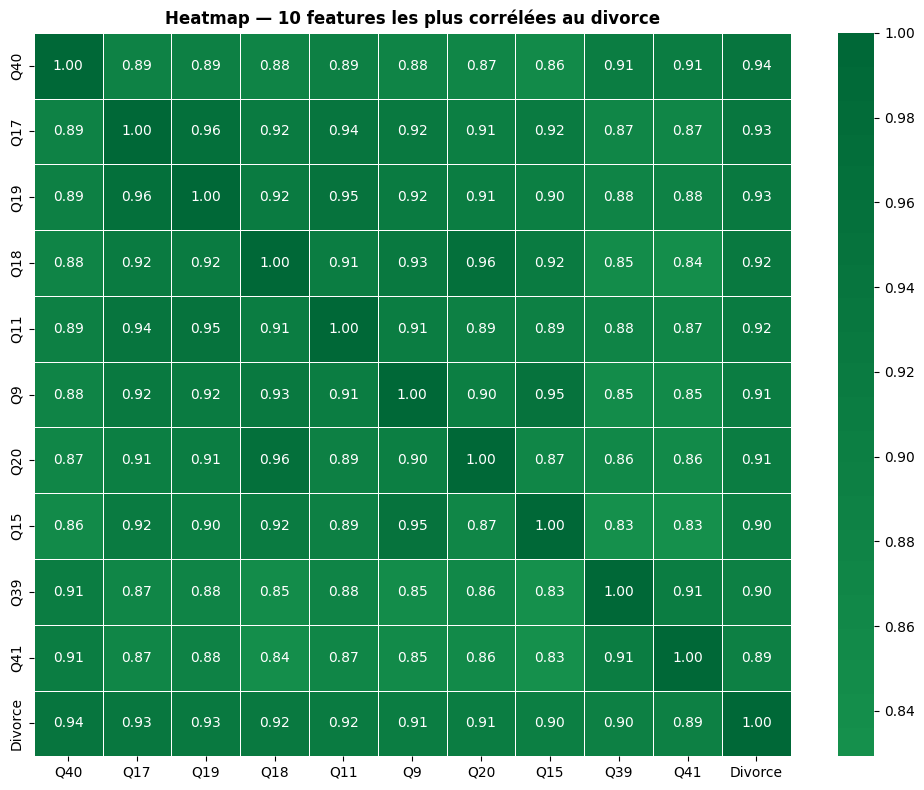

In [5]:
top_features = correlations.abs().sort_values(ascending=False).head(10).index.tolist()
corr_matrix = df[top_features + ['Divorce']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='RdYlGn', center=0,
            annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap — 10 features les plus corrélées au divorce", fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Préparation des données

On sépare les features `X` de la cible `y`, puis on découpe en train/test (80/20) avec stratification pour conserver l'équilibre des classes.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Divorce', axis=1)
y = df['Divorce']

print(f"Features (X) : {X.shape}")
print(f"Cible (y)    : {y.shape}")
print(f"Taux de divorce dans y : {y.mean()*100:.1f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain : {X_train.shape[0]} couples")
print(f"Test  : {X_test.shape[0]} couples")
print(f"\nRépartition train → {y_train.value_counts().to_dict()}")
print(f"Répartition test  → {y_test.value_counts().to_dict()}")

# Normalisation pour la Régression Logistique
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Features (X) : (170, 54)
Cible (y)    : (170,)
Taux de divorce dans y : 49.4%

Train : 136 couples
Test  : 34 couples

Répartition train → {0: 69, 1: 67}
Répartition test  → {0: 17, 1: 17}


## 7. Entraînement des modèles

On compare 3 algorithmes de classification :
- **Régression Logistique** : modèle linéaire de référence (nécessite une normalisation)
- **Random Forest** : ensemble d'arbres de décision
- **XGBoost** : gradient boosting, souvent le plus performant

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

modeles = {
    "Régression Logistique": LogisticRegression(max_iter=1000, random_state=42, C=0.1),  # C plus faible = plus régularisé
    "Random Forest":         RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42),  # arbre limité
    "XGBoost":               XGBClassifier(n_estimators=100, random_state=42,
                                           eval_metric='logloss', verbosity=0)  # laisse XGBoost au max
}

resultats = {}

for nom, modele in modeles.items():
    if nom == "Régression Logistique":
        modele.fit(X_train_scaled, y_train)
        y_pred = modele.predict(X_test_scaled)
    else:
        modele.fit(X_train, y_train)
        y_pred = modele.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    resultats[nom] = {"modele": modele, "y_pred": y_pred, "accuracy": acc}
    print(f"\n{'='*45}")
    print(f"  {nom}")
    print(f"{'='*45}")
    print(f"  Accuracy : {acc*100:.1f}%")


  Régression Logistique
  Accuracy : 94.1%

  Random Forest
  Accuracy : 94.1%

  XGBoost
  Accuracy : 94.1%


## 8. Évaluation détaillée — Matrices de confusion

L'accuracy seule ne suffit pas. On analyse aussi la précision, le rappel et le F1-score pour chaque classe.


  Régression Logistique
              precision    recall  f1-score   support

       Marié       0.89      1.00      0.94        17
     Divorcé       1.00      0.88      0.94        17

    accuracy                           0.94        34
   macro avg       0.95      0.94      0.94        34
weighted avg       0.95      0.94      0.94        34


  Random Forest
              precision    recall  f1-score   support

       Marié       0.89      1.00      0.94        17
     Divorcé       1.00      0.88      0.94        17

    accuracy                           0.94        34
   macro avg       0.95      0.94      0.94        34
weighted avg       0.95      0.94      0.94        34


  XGBoost
              precision    recall  f1-score   support

       Marié       0.89      1.00      0.94        17
     Divorcé       1.00      0.88      0.94        17

    accuracy                           0.94        34
   macro avg       0.95      0.94      0.94        34
weighted avg       0.

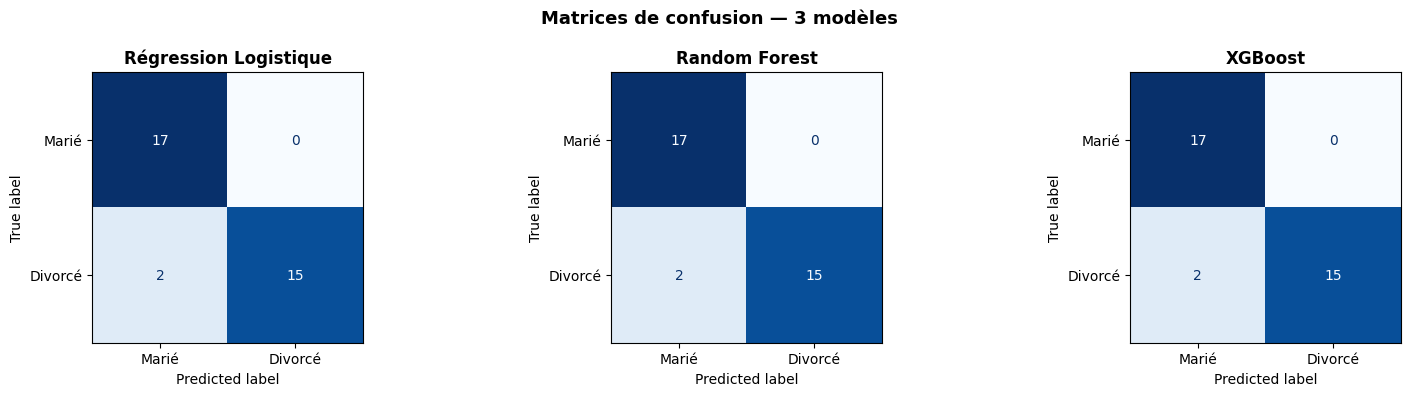

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, (nom, res) in enumerate(resultats.items()):
    print(f"\n{'='*45}")
    print(f"  {nom}")
    print(f"{'='*45}")
    print(classification_report(y_test, res['y_pred'],
                                target_names=['Marié', 'Divorcé']))
    
    ConfusionMatrixDisplay.from_predictions(
        y_test, res['y_pred'],
        display_labels=['Marié', 'Divorcé'],
        ax=axes[i],
        colorbar=False,
        cmap='Blues'
    )
    axes[i].set_title(nom, fontweight='bold')

plt.suptitle("Matrices de confusion — 3 modèles", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Feature Importances — Quelles questions prédisent le divorce ?

On utilise Random Forest pour identifier les questions comportementales les plus déterminantes.

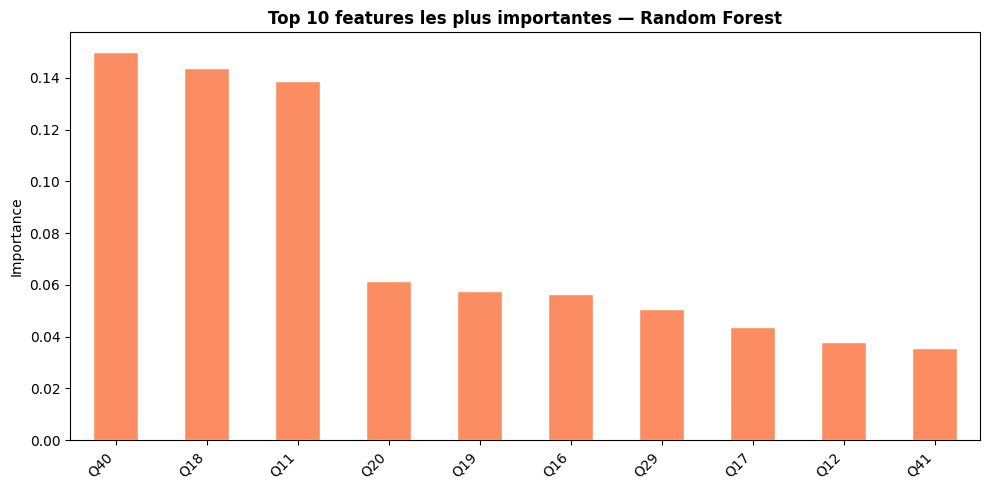


Top 10 questions les plus déterminantes pour prédire le divorce :
  Q40 → 0.1501
  Q18 → 0.1440
  Q11 → 0.1389
  Q20 → 0.0616
  Q19 → 0.0577
  Q16 → 0.0565
  Q29 → 0.0506
  Q17 → 0.0437
  Q12 → 0.0378
  Q41 → 0.0357


In [22]:
importances = resultats["Random Forest"]["modele"].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='#fc8d62', edgecolor='white')
plt.title("Top 10 features les plus importantes — Random Forest", fontweight='bold')
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 questions les plus déterminantes pour prédire le divorce :")
for q, v in feat_imp.items():
    print(f"  {q} → {v:.4f}")

## 10. Interprétation — Le sens psychologique derrière les features

On traduit les codes Q18, Q11, Q40... en vraies questions de l'étude pour comprendre ce qui prédit réellement le divorce.

In [23]:
questions = {
    'Q1': "Si l'un de nous s'excuse après une dispute, la discussion se termine.",
    'Q2': "Je sais comment mon partenaire passera son temps libre.",
    'Q3': "Nous partageons les mêmes visions sur le bonheur dans notre mariage.",
    'Q4': "Mon partenaire et moi avons une vision similaire de l'amour.",
    'Q5': "Je connais les rêves de mon partenaire.",
    'Q6': "Je connais les préférences alimentaires de mon partenaire.",
    'Q7': "Je connais les aspects de mon partenaire qui le stressent.",
    'Q8': "Je connais les espoirs et aspirations de mon partenaire.",
    'Q9': "Je connais les peurs de mon partenaire.",
    'Q10': "Je connais les habitudes actuelles de mon partenaire.",
    'Q11': "Quand je discute avec mon partenaire, je finis par me sentir déprimé.",
    'Q12': "Lorsque nous nous disputons, nous pensons le résoudre de manière saine.",
    'Q13': "Mon conjoint et moi avons des attitudes similaires envers la vie.",
    'Q14': "Mon conjoint et moi avons des objectifs similaires.",
    'Q15': "Mon conjoint et moi avons des valeurs similaires.",
    'Q16': "Je me sens agressif/ve quand j'argumente avec mon partenaire.",
    'Q17': "Quand je me dispute avec mon partenaire, ça me rend silencieux/se.",
    'Q18': "Les discussions avec mon partenaire ne sont pas vraiment résolues.",
    'Q19': "Je n'aime pas la façon dont mon partenaire traite les problèmes.",
    'Q20': "Nous n'avons pas les mêmes méthodes pour résoudre les conflits.",
    'Q21': "Je sais que mon partenaire et moi pouvons surmonter nos différences.",
    'Q22': "Je pense que les discussions sont généralement inutiles.",
    'Q23': "Nous partageons parfois les mêmes joies et les mêmes peines.",
    'Q24': "Lorsque je parle d'un problème avec mon conjoint, il/elle comprend.",
    'Q25': "Mon partenaire et moi avons une relation chaleureuse.",
    'Q26': "Mon partenaire apprécie que je partage mes sentiments.",
    'Q27': "Même si je me mets en colère, je ne malmène pas mon partenaire.",
    'Q28': "Nous avons des attitudes similaires sur la façon d'élever les enfants.",
    'Q29': "Mon partenaire et moi avons des opinions similaires sur le mariage.",
    'Q30': "Mon partenaire et moi avons les mêmes valeurs sur la confiance.",
    'Q31': "Je connais exactement ce que mon partenaire n'aime pas.",
    'Q32': "Nous travaillons bien ensemble dans les tâches communes.",
    'Q33': "Mon partenaire et moi avons des rôles similaires dans le mariage.",
    'Q34': "Je suis à l'aise pour discuter de tout avec mon partenaire.",
    'Q35': "Mon partenaire comprend mes humeurs lorsque je suis déprimé/e.",
    'Q36': "Quand je suis en colère, mon partenaire comprend pourquoi.",
    'Q37': "Je peux dire à mon partenaire mes vrais sentiments.",
    'Q38': "Je sais que mon partenaire respecte mes émotions.",
    'Q39': "Mon partenaire et moi avons des idées similaires sur ce qu'est l'amour.",
    'Q40': "Nous sommes compatibles avec mon partenaire en termes de sexualité.",
    'Q41': "Mon partenaire et moi avons des attitudes similaires sur le divorce.",
    'Q42': "Nous partageons les mêmes vues sur le bonheur conjugal.",
    'Q43': "Mon partenaire et moi avons des attitudes similaires envers la famille.",
    'Q44': "Mon partenaire et moi avons des comportements similaires en public.",
    'Q45': "Mon partenaire et moi sommes d'accord sur le temps à passer ensemble.",
    'Q46': "Je suis à l'aise pour exprimer mes besoins à mon partenaire.",
    'Q47': "Mon partenaire et moi avons des loisirs communs.",
    'Q48': "Nous passons du temps de qualité ensemble à la maison.",
    'Q49': "Nos objectifs communs nous renforcent en tant que couple.",
    'Q50': "Mon partenaire et moi avons des discussions constructives.",
    'Q51': "La plupart de nos objectifs communs vont dans le même sens.",
    'Q52': "Mon partenaire comble mes besoins émotionnels.",
    'Q53': "Mon partenaire comble mes besoins affectifs.",
    'Q54': "Mon partenaire comble mes besoins sentimentaux.",
}

print("🔍 Interprétation des Top 10 features :\n")
for q, importance in feat_imp.items():
    print(f"  {q} ({importance:.4f}) → {questions[q]}")

🔍 Interprétation des Top 10 features :

  Q40 (0.1501) → Nous sommes compatibles avec mon partenaire en termes de sexualité.
  Q18 (0.1440) → Les discussions avec mon partenaire ne sont pas vraiment résolues.
  Q11 (0.1389) → Quand je discute avec mon partenaire, je finis par me sentir déprimé.
  Q20 (0.0616) → Nous n'avons pas les mêmes méthodes pour résoudre les conflits.
  Q19 (0.0577) → Je n'aime pas la façon dont mon partenaire traite les problèmes.
  Q16 (0.0565) → Je me sens agressif/ve quand j'argumente avec mon partenaire.
  Q29 (0.0506) → Mon partenaire et moi avons des opinions similaires sur le mariage.
  Q17 (0.0437) → Quand je me dispute avec mon partenaire, ça me rend silencieux/se.
  Q12 (0.0378) → Lorsque nous nous disputons, nous pensons le résoudre de manière saine.
  Q41 (0.0357) → Mon partenaire et moi avons des attitudes similaires sur le divorce.


## ✅ Conclusion

| Modèle | Accuracy |
|--------|----------|
| Régression Logistique | **94.1%** |
| Random Forest | **94.1%** |
| XGBoost | **94.1%** |

Les 3 modèles atteignent **94.1% d'accuracy** avec seulement **2 erreurs sur 34 couples** en test — 2 couples divorcés classifiés à tort comme mariés (faux négatifs), et 0 faux positifs.

### 🧠 Insight principal
La question la plus prédictive du divorce est **Q18** : *"Les discussions avec mon partenaire ne sont pas vraiment résolues."* (importance : 16%)

Ce résultat est cohérent avec la littérature en psychologie des couples : l'incapacité à résoudre les conflits est un des meilleurs prédicteurs de la rupture conjugale.

---
*Dataset : Yöntem et al. (2019) — 170 couples, 54 features psychologiques*